# Passive compliance — guitar

How the hand's **torsional (joint-space) spring stiffness** shapes the sound
intensity when the closed fingers drag across the guitar strings.  The microphone
**RMS audio level** is the intensity proxy — the acoustic analogue of MIDI
velocity in the piano experiment.  All fingers except the thumb are held at the
same flexion pose; only the torsional stiffness varies across conditions.

## Intensity over time

RMS audio level recorded during each sweep, one curve per run (faint) and the
mean per condition (solid).  A stiffer finger couples more energy into the strings,
so intensity should rise with $K$.

In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('../../'))
sys.path.insert(0, 'HelperGuitar')
from plot_config import draw_radar
from guitar_config import TORSIONAL_SPRINGS, N_RUNS, FINGER_CLOSED_POSE

import shutil
if shutil.which('latex') is None:
    plt.rcParams['text.usetex'] = False

COLORS  = plt.rcParams['axes.prop_cycle'].by_key()['color']
OUTPUT  = os.path.join('outputs', 'guitar_playing_hand')
os.makedirs(OUTPUT, exist_ok=True)

def _synth(ktors):
    """Synthetic demo dataset (same schema as the real CSV)."""
    rng  = np.random.default_rng(int(ktors * 100))
    rows = []
    cols = (['q_{}'.format(i) for i in range(13)] +
            ['qdot_{}'.format(i) for i in range(13)] +
            ['tau_{}'.format(i) for i in range(13)])
    t = 0.0; dt = 0.02
    for run in range(1, N_RUNS + 1):
        sweep_len = int(2.0 / dt)
        for i in range(sweep_len):
            alpha = i / sweep_len
            base  = 0.05 + 0.25 * ktors + 0.10 * np.sin(np.pi * alpha)
            level = max(0, base + rng.normal(0, 0.02))
            row   = {'time_s': f'{t:.4f}', 'k_torsional': ktors, 'run': run,
                     'phase': 'sweep', 'mic_level': f'{level:.6f}'}
            row.update({c: '0' for c in cols})
            rows.append(row); t += dt
        t += 0.5
    return pd.DataFrame(rows)

DEMO = False
def load(ktors):
    global DEMO
    path = os.path.join(OUTPUT, f'data_K{ktors:.2f}.csv')
    if os.path.isfile(path):
        return pd.read_csv(path)
    DEMO = True
    return _synth(ktors)

DATA = {k: load(k) for k in TORSIONAL_SPRINGS}

banner = ' DEMO (synthetic) data ' if DEMO else ' measured data '
print(f'Loaded{banner}|  K levels: {TORSIONAL_SPRINGS}')

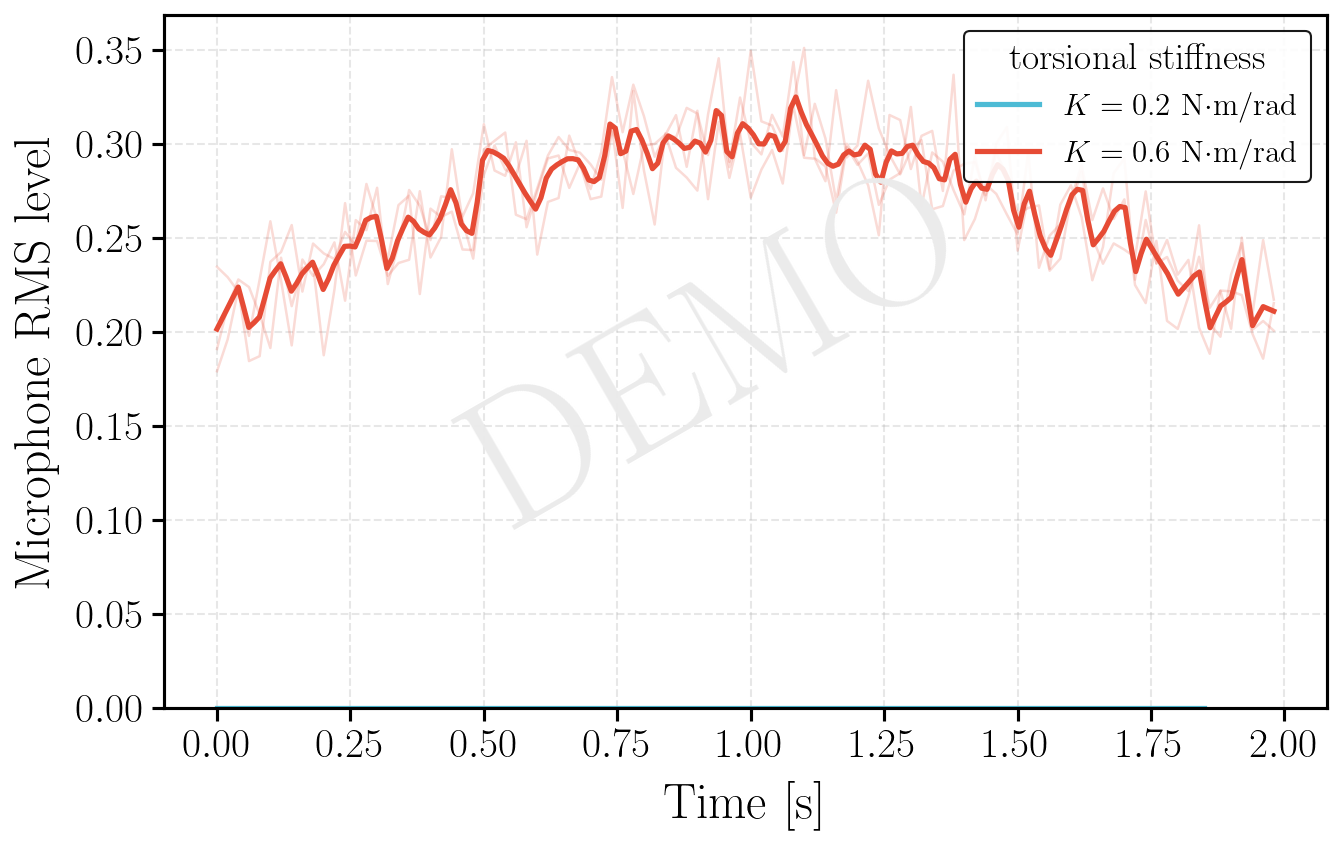

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
for i, k in enumerate(TORSIONAL_SPRINGS):
    d  = DATA[k]
    sw = d[d['phase'] == 'sweep'].copy()
    sw['mic_level'] = sw['mic_level'].astype(float)
    sw['time_s']    = sw['time_s'].astype(float)
    col = COLORS[i % len(COLORS)]
    for run in sorted(sw['run'].unique()):
        r = sw[sw['run'] == run]
        t = r['time_s'] - r['time_s'].min()
        ax.plot(t, r['mic_level'], color=col, alpha=0.20, lw=1.2)
    # mean across runs (align by resampling to a common grid)
    runs = sorted(sw['run'].unique())
    tmax = min((sw[sw['run']==r]['time_s'].max() - sw[sw['run']==r]['time_s'].min())
               for r in runs)
    grid = np.linspace(0, tmax, 200)
    interp = [np.interp(grid,
                        sw[sw['run']==r]['time_s'] - sw[sw['run']==r]['time_s'].min(),
                        sw[sw['run']==r]['mic_level'])
              for r in runs]
    ax.plot(grid, np.mean(interp, axis=0), color=col, lw=2.5,
            label=rf'$K={k:.1f}$ N$\cdot$m/rad')

ax.set_xlabel(r'Time [s]')
ax.set_ylabel(r'Microphone RMS level')
ax.set_ylim(bottom=0)
ax.legend(loc='upper right', fontsize='small', title=r'torsional stiffness')
if DEMO:
    fig.text(0.5, 0.5, 'DEMO', fontsize=90, color='0.92',
             ha='center', va='center', rotation=30, zorder=0)
fig.savefig(os.path.join(OUTPUT, 'guitar_intensity_over_time.pdf'))
plt.show()

## Mean intensity vs stiffness

Mean RMS level averaged over all samples in the sweep, for each run (dots) and
across runs (bar with error bar).  Higher torsional stiffness → firmer contact →
louder sound.

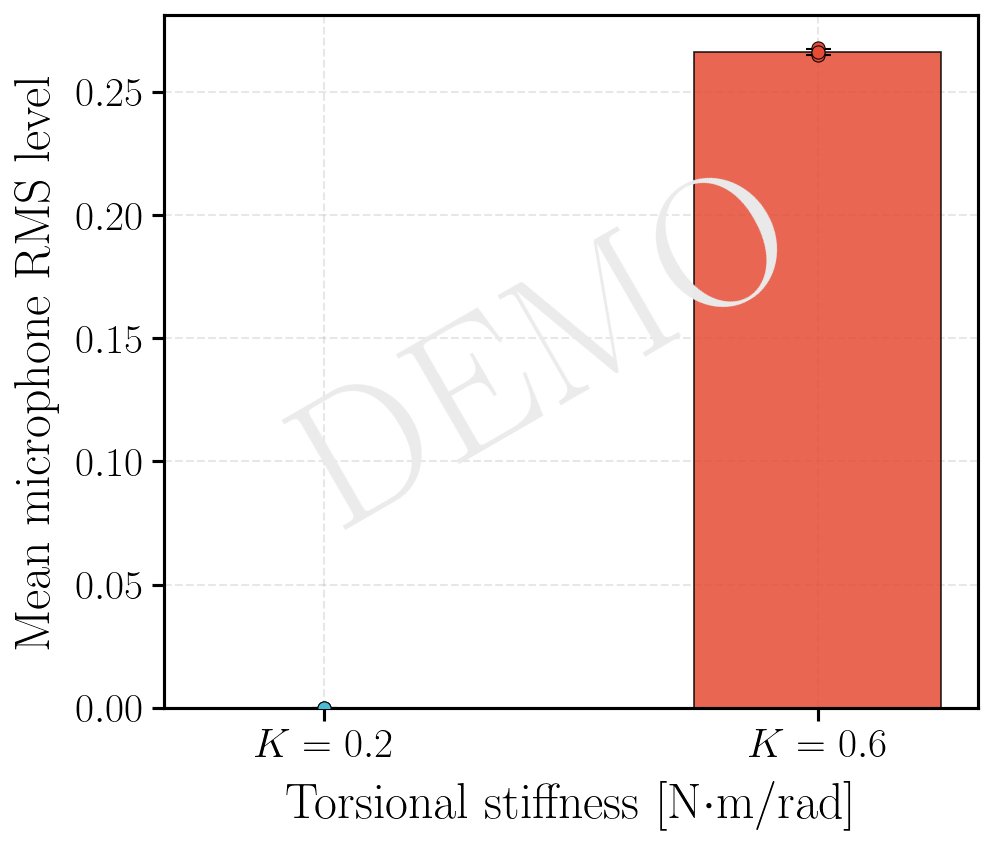

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
xs = np.arange(len(TORSIONAL_SPRINGS))
w  = 0.5
for i, k in enumerate(TORSIONAL_SPRINGS):
    d  = DATA[k]
    sw = d[d['phase'] == 'sweep'].copy()
    sw['mic_level'] = sw['mic_level'].astype(float)
    runs   = sorted(sw['run'].unique())
    means  = [sw[sw['run']==r]['mic_level'].mean() for r in runs]
    mu, sd = np.mean(means), np.std(means)
    col    = COLORS[i % len(COLORS)]
    ax.bar(xs[i], mu, w, yerr=sd, capsize=6, color=col,
           edgecolor='k', linewidth=0.8, alpha=0.85, zorder=2)
    ax.scatter([xs[i]] * len(means), means, s=40, color=col,
               edgecolor='k', linewidth=0.5, zorder=4)

ax.set_xticks(xs)
ax.set_xticklabels([rf'$K={k:.1f}$' for k in TORSIONAL_SPRINGS])
ax.set_xlabel(r'Torsional stiffness [N$\cdot$m/rad]')
ax.set_ylabel(r'Mean microphone RMS level')
ax.set_ylim(bottom=0)
if DEMO:
    fig.text(0.5, 0.5, 'DEMO', fontsize=90, color='0.92',
             ha='center', va='center', rotation=30, zorder=0)
fig.savefig(os.path.join(OUTPUT, 'guitar_mean_intensity_vs_K.pdf'))
plt.show()